In [32]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.datasets import load_iris

In [69]:
# 1. Load data and prepare features/target

In [65]:
iris = load_iris()

In [66]:
import seaborn as sns 

In [67]:
df = sns.load_dataset("iris")
X = df.iloc[:, :-1]
y = iris.target

In [68]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# 2. Split dataset into training and testing sets

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [70]:
# 3. Initialize and train the Pre-Pruned Decision Tree model

In [49]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X_train, y_train)

In [ ]:
# 4. Visualize the decision tree structure

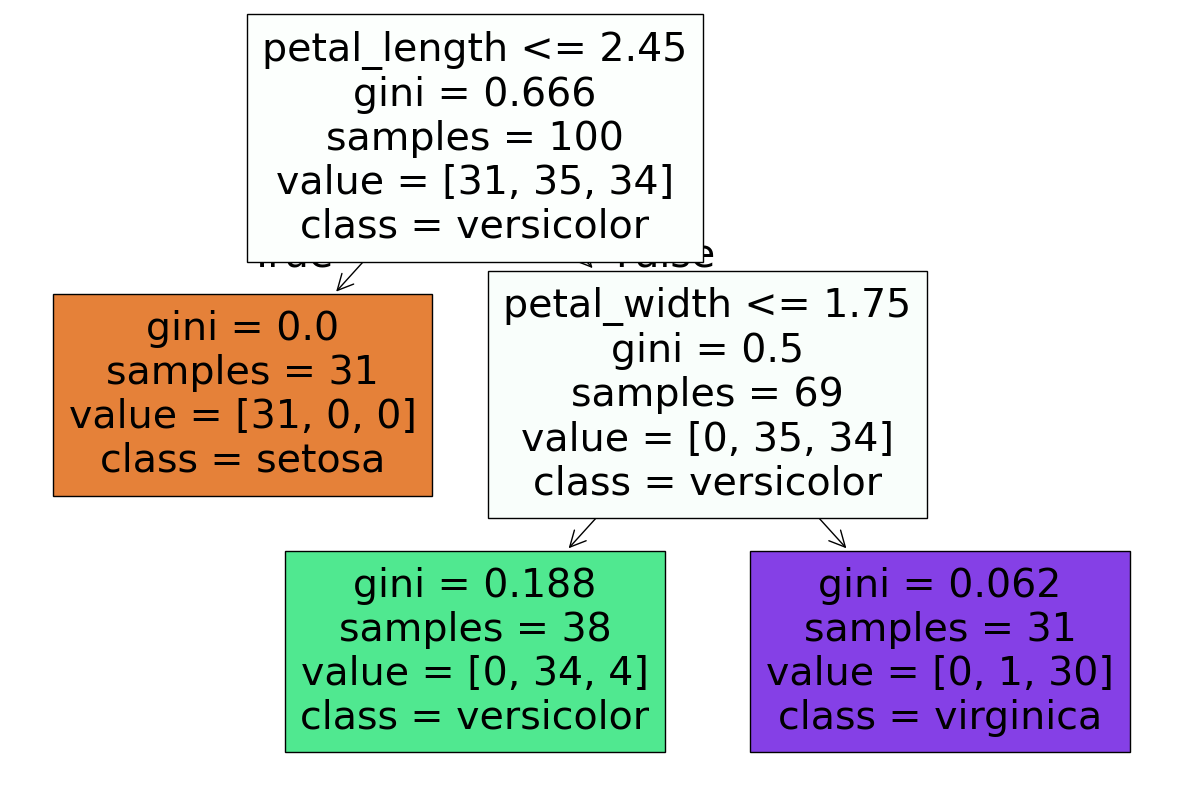

In [64]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(clf,filled=True)

In [71]:
# 5. Make predictions on test data

In [72]:
y_pred = clf.predict(X_test)
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0, 1, 1, 2, 1, 2])

In [73]:
# 6. Evaluate and print model performance

In [74]:
score = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {score:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy Score: 0.9800

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.94      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



In [80]:
### Pre-prunning
# 1. Define the hyperparameter grid for tuning the Decision Tree

parameter = {
    "criterion": ["gini", "entropy", "log_loss"],  # Metrics to measure split quality
    "splitter": ["best", "random"],  # Strategy used to choose the split at each node
    "max_depth": [1, 2, 3, 4, 5],  # Maximum depth of the tree to prevent overfitting
    "max_features": ["sqrt", "log2", None],  # Number of features to consider when looking for the best split
    "ccp_alpha": [0.0, 0.01, 0.02, 0.05, 0.1],  # Cost-Complexity Pruning parameter (0.0 means no pruning)
}


In [81]:
# 2. Instantiate a baseline Decision Tree Classifier model
from sklearn.model_selection import GridSearchCV
treemodel = DecisionTreeClassifier()

In [ ]:
# 3. Configure the GridSearchCV object
# It tests every combination in 'parameter', evaluates using 5-fold cross-validation, and tracks accuracy
cv = GridSearchCV(
    estimator=treemodel, param_grid=parameter, cv=5, scoring="accuracy"
)

In [93]:
# 4. Run the Grid Search on the training data to find the best configuration
cv.fit(X_train, y_train)

/home/prakharj/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
1050 fits failed out of a total of 3150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1050 fits failed with the following error:
Traceback (most recent call last):
  File "/home/prakharj/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/prakharj/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/home/prakharj/anaconda3/lib/python3.13/site-packages/sk

,estimator,DecisionTreeClassifier()
,param_grid,"{'ccp_alpha': [1, 2, ...], 'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], ...}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [94]:
# 5. Extract and print the best hyperparameter combination found by the search
print("Best Hyperparameters Found:")
print(cv.best_params_)
print("-" * 50)

Best Hyperparameters Found:
{'ccp_alpha': 1, 'criterion': 'gini', 'max_depth': 1, 'max_features': 'sqrt', 'splitter': 'best'}
--------------------------------------------------


In [84]:
cv.predict(X_train)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [88]:
# 6. Use the optimized model to make predictions on the unseen testing data
y_pred = cv.predict(X_test)

In [89]:
from sklearn.metrics import accuracy_score , classification_report

In [95]:
# 7. Calculate the overall model accuracy score by comparing predictions against true test labels
score = accuracy_score(y_test, y_pred)
print(f"Optimized Model Accuracy: {score:.4f}\n")

Optimized Model Accuracy: 0.3000



In [96]:
# 8. Generate and display a detailed report including Precision, Recall, and F1-Score for each class
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Classification Report:
              precision    recall  f1-score   support

      setosa       0.00      0.00      0.00        19
  versicolor       0.30      1.00      0.46        15
   virginica       0.00      0.00      0.00        16

    accuracy                           0.30        50
   macro avg       0.10      0.33      0.15        50
weighted avg       0.09      0.30      0.14        50



/home/prakharj/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/prakharj/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/prakharj/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape